<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Customer_Personality_Analysis(Clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. People¶
* ID: Unique customer identifier
* Year_Birth: Customer's year of birth
* Education: Customer's level of education
* Marital_Status: Customer's marital status
* Income: Customer's annual household income
* Kidhome: Number of children in the household
* Teenhome: Number of teenagers in the household
* Dt_Customer: Date the customer enrolled with the company
* Recency: Number of days since the last purchase
* Complain: Indicates if the customer filed a complaint in the last 2 years (1 = Yes, 0 = No)

2. Products
* MntWines: Amount spent on wine in the last 2 years
* MntFruits: Amount spent on fruits in the last 2 years
* MntMeatProducts: Amount spent on meat products in the last 2 years
* MntFishProducts: Amount spent on fish products in the last 2 years
* MntSweetProducts: Amount spent on sweets in the last 2 years
* MntGoldProds: Amount spent on gold products in the last 2 years

3. Promotion¶
* NumDealsPurchases: Number of purchases made with a discount
* AcceptedCmp1: Accepted the offer in the 1st campaign (1 = Yes, 0 = No)
* AcceptedCmp2: Accepted the offer in the 2nd campaign (1 = Yes, 0 = No)
* AcceptedCmp3: Accepted the offer in the 3rd campaign (1 = Yes, 0 = No)
* AcceptedCmp4: Accepted the offer in the 4th campaign (1 = Yes, 0 = No)
* AcceptedCmp5: Accepted the offer in the 5th campaign (1 = Yes, 0 = No)
Response: Accepted the offer in the last campaign (1 = Yes, 0 = No)

4. Place
* NumWebPurchases: Number of purchases made through the company’s website
* NumCatalogPurchases: Number of purchases made via catalogues
* NumStorePurchases: Number of purchases made in stores
* NumWebVisitsMonth: Number of website visits in the last month


In [13]:
!pip install -q yellowbrick

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import seaborn as sns

from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn import metrics

import datetime
import warnings
import sys

warnings.simplefilter("ignore")
sns.set_style("whitegrid", rc={"axes.facecolor":"#FFF9ED", "figure.facecolor":"#FFF9ED"})
pal = ["#2E5077", "#4DA1A9", "#79D7BE", "#BCCCDC"]
cmap = ListedColormap(["#2E5077", "#4DA1A9", "#79D7BE", "#BCCCDC"])

In [5]:
import pandas as pd
data = pd.read_csv("/content/sample_data/marketing_campaign.csv", sep = '\t')
data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


From the above output, we can conclude the following:

* There are missing values in the Income column.
* The Dt_Customer column, which indicates the date a customer joined, is not parsed as a DateTime object.
* The dataset contains categorical features (with dtype: object), which will need to be encoded into numeric format later.
* To address the missing values, we will first drop rows with missing Income values.

In [9]:
data = data.dropna()
print("new shape:", data.shape)

new shape: (2216, 29)


In [10]:
useless_cols = ['ID', "Dt_Customer"]
data.drop(useless_cols, axis=1, inplace=True)

# 3. Exploratory Data Analyses

In [11]:
print("Categories in: Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Categories in: Education:\n", data["Education"].value_counts())

Categories in: Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Categories in: Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


Feature Engineering
In the next section, I will perform the following steps to engineer new features:

* Age: Derive the customer's age from the "Year_Birth" column.
* Spent: Create a feature to represent the total amount spent by the customer across all categories over the last two years.
* Living_With: Extract the living situation of customers from the "Marital_Status" column.
* Children: Calculate the total number of children in a household by combining "Kidhome" and "Teenhome".
* Family_Size: Determine the overall family size, including adults and children.
* Is_Parent: Add a feature to indicate whether the customer has children.
* Education (Simplified): Group the values in the "Education" column into three simplified categories.
Drop redundant features to reduce noise and redundancy in the dataset.

In [14]:
# Calculate the age of customers as of 2021
data["Age"] = 2021 - data["Year_Birth"]

# Compute total spending across all product categories
data["Spent"] = (data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] +
                 data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"])

# Derive living situation based on marital status
data["Living_With"] = data["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Absurd": "Alone", "Widow": "Alone",
    "YOLO": "Alone", "Divorced": "Alone", "Single": "Alone"
})

# Calculate total children in the household
data["Children"] = data["Kidhome"] + data["Teenhome"]

# Determine the total family size, including adults and children
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner": 2}) + data["Children"]

# Create a feature indicating parenthood status
data["Is_Parent"] = np.where(data["Children"] > 0, 1, 0)

# Simplify education levels into three categories
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate"
})

# Rename columns for clarity
data = data.rename(columns={
    "MntWines": "Wines", "MntFruits": "Fruits",
    "MntMeatProducts": "Meat", "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"
})

# Drop redundant features
to_drop = ["Marital_Status", "Z_CostContact", "Z_Revenue", "Year_Birth"]
data = data.drop(to_drop, axis=1)

In [15]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.073105,0.064079,0.013538,0.009477,0.150271,52.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.260367,0.244950,0.115588,0.096907,0.357417,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,62.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,128.000000,2525.000000,3.000000,5.000000,1.000000


* The above statistics reveal some discrepancies in the data, particularly in the mean and maximum values for Income and Age. Note that the maximum age is 128 years, which is likely due to the dataset being outdated (age calculated as of 2021).
* To gain a broader understanding of the data, I will analyze it further.
* I will visualize some of the selected features to identify patterns and outliers.

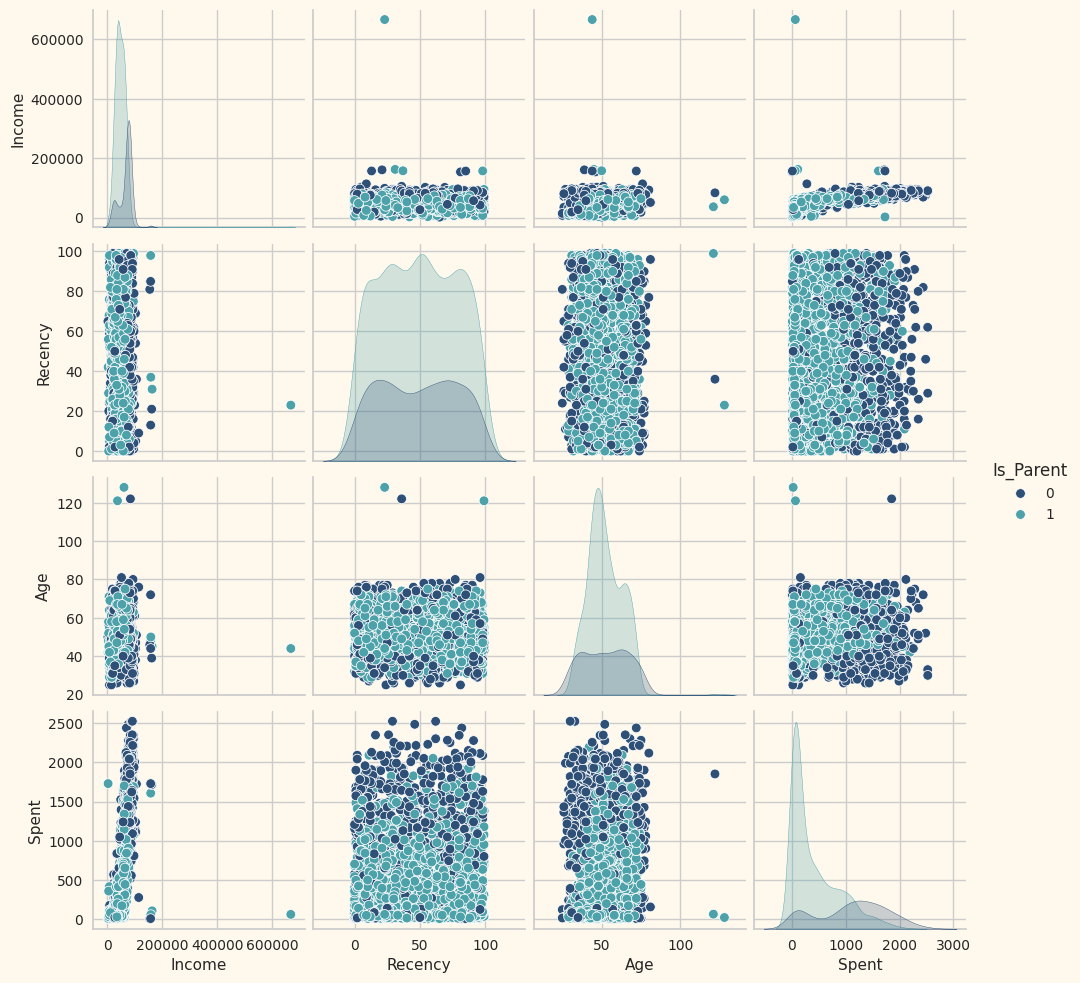

In [16]:
# Visualize relationships between core features with a focus on parenthood status
core_features = ["Income", "Recency", "Age", "Spent", "Is_Parent"]

# Create a pairplot with color coding based on 'Is_Parent'
palette = ['#4DA1A9', '#808080']
sns.pairplot(data[core_features], hue="Is_Parent", palette=pal)
plt.show()

It is evident that there are a few outliers in the Income and Age features. These outliers will be removed to improve the quality of the analysis.

In [17]:
# Set thresholds for Age and Income to remove outliers
age_threshold = 90
income_threshold = 600000

# Filter data by applying the thresholds
data = data[(data["Age"] < age_threshold) & (data["Income"] < income_threshold)]

# Display the new shape of the dataset
print("New shape:", data.shape)

New shape: (2212, 29)


## Correlation

<Axes: >

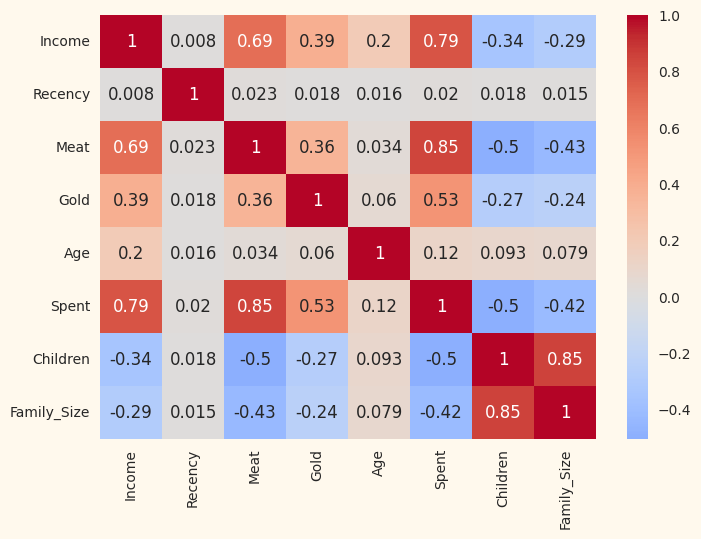

In [18]:
# Define columns to compute correlations
corr_cols = ['Income', 'Recency', 'Meat', 'Gold', 'Age', 'Spent', 'Children', 'Family_Size']

# Compute the correlation matrix for the selected columns
corrmat = data[corr_cols].corr(numeric_only=True)

# Plot the heatmap of correlations
plt.figure()
sns.heatmap(corrmat, annot=True, center=0, cmap='coolwarm')  # You can adjust 'cmap' as needed

The following steps will be applied to preprocess the data:

* Label Encoding: Convert categorical features into numeric values.
* Feature Scaling: Standardize the features using a standard scaler to ensure they are on the same scale.
* Dimensionality Reduction: Create a subset of the dataframe for reducing the dimensionality of the data.

In [19]:
# Identify the categorical (object) columns in the dataset
object_cols = list(data.select_dtypes('object').columns)

# Display the list of object columns
object_cols

['Education', 'Living_With']

In [20]:
# Initialize the label encoder
encoder = LabelEncoder()

# Apply label encoding to all categorical columns
for col in object_cols:
    data[col] = encoder.fit_transform(data[col])

In [21]:
# Create a copy of the original dataset
ds = data.copy()

# Drop columns related to deals accepted and promotions
cols_to_drop = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_to_drop, axis=1)

# Scale the features using StandardScaler
scaler = StandardScaler()
scaled_ds = pd.DataFrame(scaler.fit_transform(ds), columns=ds.columns)

In [22]:
scaled_ds.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,1.426865,2.503607,-0.555814,0.692181,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-1.126420,-0.571340,-1.171160,-0.132545,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,1.426865,-0.229679,1.290224,-0.544908,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.761665,-0.913000,-0.555814,0.279818,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.332600,0.111982,0.059532,-0.132545,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


Dimensionality Reduction
In classification tasks, the number of features plays a critical role. As the number of features increases, the complexity of the model grows. Many of these features are often correlated, leading to redundancy. To address this, dimensionality reduction will be applied to the selected features before passing them through a classifier.

Steps in this section:

* Perform Principal Component Analysis (PCA) for dimensionality reduction
* Plot the reduced dataframe

The dimensions will be reduced to 3 for visualization and model optimization.

In [23]:
# Perform PCA to reduce the dataset to 3 components
pca = PCA(n_components=3)
PCA_ds = pd.DataFrame(pca.fit_transform(scaled_ds), columns=["c1", "c2", "c3"])

# Display a summary of the transformed data
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
c1,2212.0,-2.120064e-16,2.877338,-5.940876,-2.552996,-0.776146,2.394880,7.411440
c2,2212.0,0.000000e+00,1.699736,-4.285505,-1.329387,-0.149709,1.244895,6.110757
c3,2212.0,-1.686415e-17,1.153616,-3.963560,-0.813114,0.140917,0.890893,2.943594


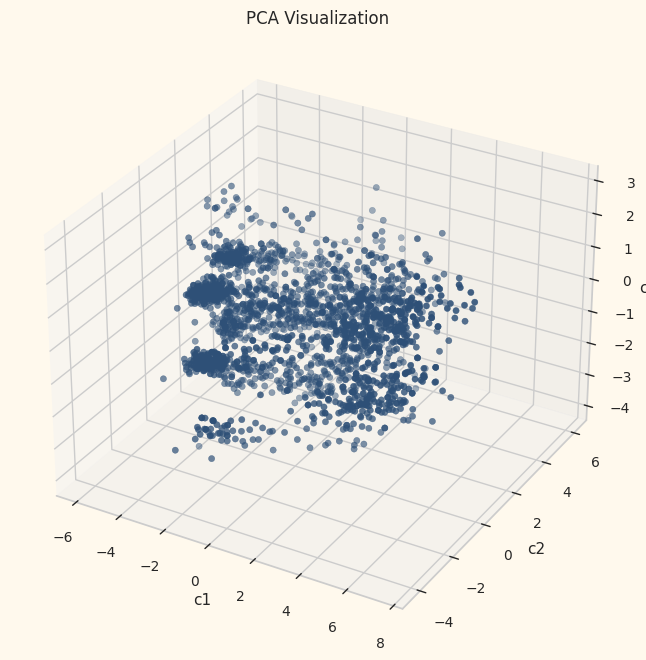

In [24]:
# Create a 3D scatter plot for PCA components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot the 3D scatter with PCA components
ax.scatter(xs=PCA_ds["c1"], ys=PCA_ds["c2"], zs=PCA_ds["c3"], c="#2E5077", marker="o")

# Set plot labels and title
ax.set_title("PCA Visualization")
ax.set_xlabel("c1")
ax.set_ylabel("c2")
ax.set_zlabel("c3")

# Show the plot
plt.show()

# 4. Data modeling:

* Satisfied by your data ?
* Run simple clustering or regression.
* Evaluate your data modeling by choosing the right evaluatiors( clustering or regression).
Make visualization.
* In this section, we will perform clustering using Agglomerative Clustering, a hierarchical method that iteratively merges examples until the desired number of clusters is reached.

Steps involved in Clustering:

* Use the Elbow Method to determine the optimal number of clusters
* Apply Agglomerative Clustering to form the clusters
* Visualize and examine the formed clusters using scatter plots

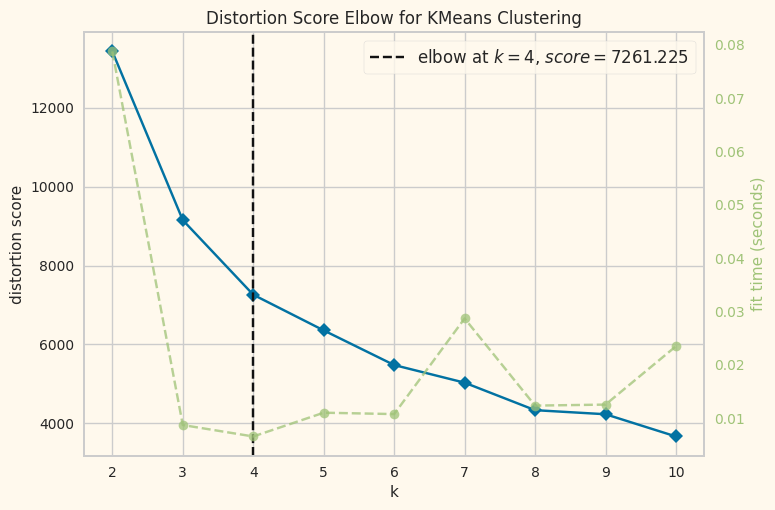

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [25]:
# Use the Elbow Method to determine the optimal number of clusters
Elbow_M = KElbowVisualizer(KMeans(), k=10)  # Set max clusters to 10
Elbow_M.fit(PCA_ds)

# Display the Elbow Method plot
Elbow_M.show()

* The above cell indicates that four will be an optimal number of clusters for this data.
* Next, we will be fitting the Agglomerative Clustering Model to get the final clusters.

In [26]:
# Apply Agglomerative Clustering to form 4 clusters
AC = AgglomerativeClustering(n_clusters=4)
yhat_AC = AC.fit_predict(PCA_ds)

# Add the cluster labels to the PCA dataframe and the original data
PCA_ds["Clusters"] = yhat_AC
data["Clusters"] = yhat_AC

# 3D distribution of Clusters

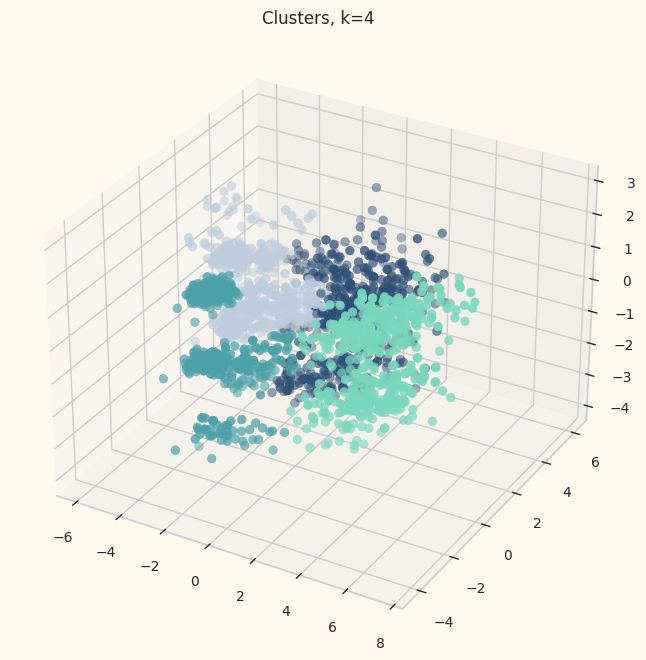

In [27]:
# Create a 3D scatter plot to visualize the clusters
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='3d')

# Plot the clusters with different colors based on the cluster labels
ax.scatter(xs=PCA_ds["c1"], ys=PCA_ds["c2"], zs=PCA_ds["c3"],
           s=40, c=PCA_ds["Clusters"], marker='o', cmap=cmap)

# Set plot title and show the visualization
ax.set_title("Clusters, k=4")
plt.show()

# Model Evaluation

* Since this is an unsupervised clustering task, there is no labeled feature available to evaluate or score the model.
* The objective of this section is to explore the patterns within the formed clusters and analyze their characteristics.
* We will examine the data with respect to the clusters through exploratory data analysis (EDA) and draw meaningful conclusions.

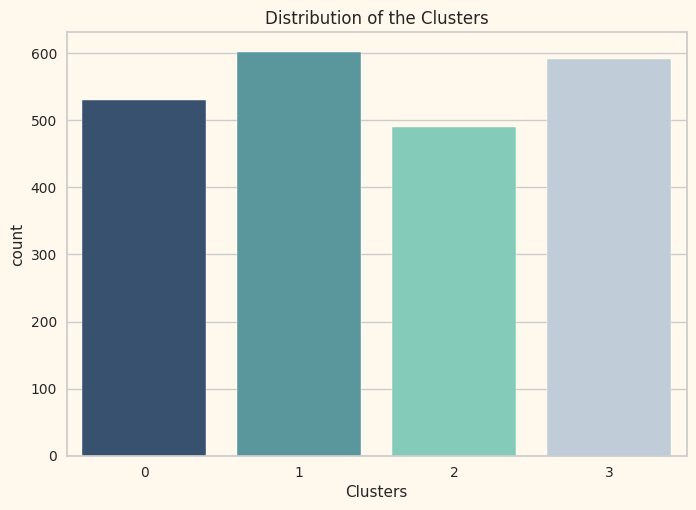

In [28]:
# Visualize the distribution of clusters using a count plot
_plot = sns.countplot(x=data["Clusters"], palette=pal)

# Set plot title and display
_plot.set_title("Distribution of the Clusters")
plt.show()

## Spent vs Income

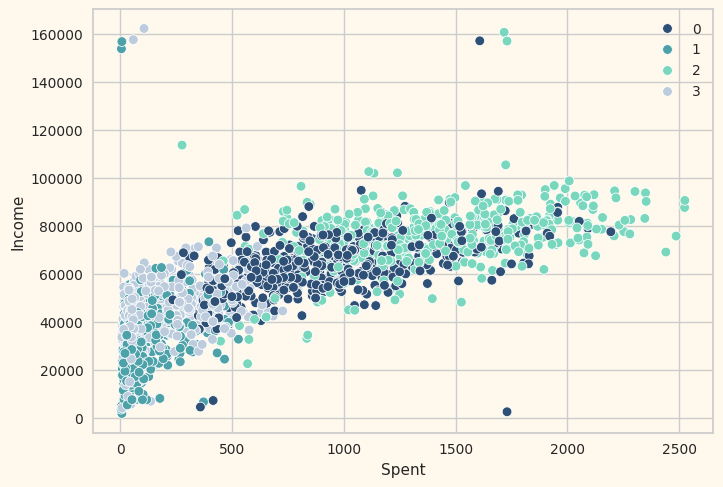

In [29]:
# Visualize the relationship between Spent and Income, colored by clusters
pl = sns.scatterplot(data=data, x=data["Spent"], y=data["Income"], hue=data["Clusters"], palette=pal)

# Display the legend and plot
plt.legend()
plt.show()

# Income vs Spending Plot – Cluster Patterns:

* Group 0: High spending & average income
* Group 1: High spending & high income(?)
* Group 2: Low spending(?) & low income
* Group 3: High spending & low income

* Next, I will explore the detailed distribution of clusters based on various product categories in the dataset: Wines, Fruits, Meat, Fish, Sweets, and Gold.

### Cluster Analysis: Spending vs Income

To understand the characteristics of each cluster, I will analyze the average 'Spent' and 'Income' for each group. This will provide insights into the purchasing behavior and financial profiles of the customer segments identified by the clustering algorithm.

Average Spent and Income per Cluster:


,Clusters,Spent,Income
0,0,929.056604,63046.354717
1,1,96.836938,30749.931780
2,2,1381.106122,75646.183673
3,3,196.169205,43944.131980


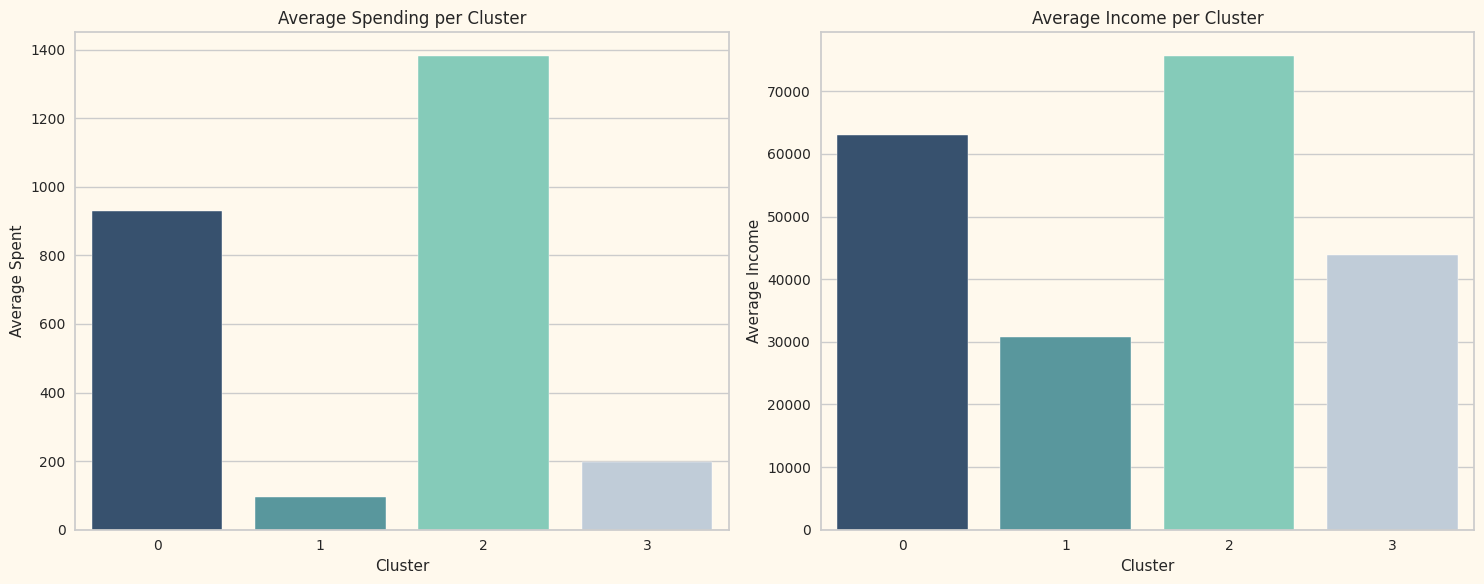

In [31]:
# Group data by clusters and calculate the mean of 'Spent' and 'Income'
cluster_summary = data.groupby('Clusters')[['Spent', 'Income']].mean().reset_index()

print("Average Spent and Income per Cluster:")
display(cluster_summary)

# Visualize the average Spent per cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
sns.barplot(x='Clusters', y='Spent', data=cluster_summary, palette=pal, ax=axes[0])
axes[0].set_title('Average Spending per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Average Spent')

# Visualize the average Income per cluster
sns.barplot(x='Clusters', y='Income', data=cluster_summary, palette=pal, ax=axes[1])
axes[1].set_title('Average Income per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average Income')

plt.tight_layout()
plt.show()

### Cluster Interpretation: Spending and Income Levels

Based on the average 'Spent' and 'Income' values derived from the `cluster_summary`, I will now classify each cluster into descriptive categories (e.g., 'Low Spenders, Low Income', 'High Spenders, High Income') to provide a clear interpretation of the customer segments.

Let's define the thresholds for 'low', 'medium', and 'high' spending and income based on the observed ranges in the `cluster_summary`.

In [37]:
# Define thresholds for categorization based on cluster_summary values
spent_bins = pd.cut(cluster_summary['Spent'], bins=3, labels=['low', 'medium', 'high'])
income_bins = pd.cut(cluster_summary['Income'], bins=3, labels=['low', 'medium', 'high'])

cluster_summary['Spent_Category'] = spent_bins
cluster_summary['Income_Category'] = income_bins

# Map descriptions to clusters based on the categories
def get_cluster_description(row):
    spent_cat = row['Spent_Category']
    income_cat = row['Income_Category']

    if spent_cat == 'high' and income_cat == 'high':
        return 'High Spenders, High Income'
    elif spent_cat == 'medium' and income_cat == 'medium':
        return 'Medium Spenders, Medium Income'
    elif spent_cat == 'low' and income_cat == 'low':
        return 'Low Spenders, Low Income'
    elif spent_cat == 'high' and income_cat == 'medium':
        return 'High Spenders, Medium Income'
    elif spent_cat == 'medium' and income_cat == 'low':
        return 'Medium Spenders, Low Income'
    elif spent_cat == 'low' and income_cat == 'medium':
        return 'Low Spenders, Medium Income'
    elif spent_cat == 'high' and income_cat == 'low':
        return 'High Spenders, Low Income'
    elif spent_cat == 'medium' and income_cat == 'high':
        return 'Medium Spenders, High Income'
    else:
        return 'Undefined'

cluster_summary['Description'] = cluster_summary.apply(get_cluster_description, axis=1)

print("Cluster Summary with Descriptions:")
display(cluster_summary)

Cluster Summary with Descriptions:


,Clusters,Spent,Income,Spent_Category,Income_Category,Description
0,0,929.056604,63046.354717,medium,high,"Medium Spenders, High Income"
1,1,96.836938,30749.931780,low,low,"Low Spenders, Low Income"
2,2,1381.106122,75646.183673,high,high,"High Spenders, High Income"
3,3,196.169205,43944.131980,low,low,"Low Spenders, Low Income"


### Detailed Cluster Analysis by Product Categories

Now that we have characterized the clusters by their overall spending and income, let's delve deeper into their specific purchasing behaviors across different product categories (Wines, Fruits, Meat, Fish, Sweets, and Gold). This analysis will reveal which product types are favored by each customer segment.

Average Spending on Product Categories per Cluster:


,Clusters,Wines,Fruits,Meat,Fish,Sweets,Gold
0,0,544.311321,35.645283,191.200000,49.109434,38.100000,70.690566
1,1,32.460899,6.490849,24.314476,9.787022,6.767055,17.016639
2,2,613.030612,64.624490,468.857143,94.187755,65.379592,75.026531
3,3,113.226734,6.399323,40.238579,8.827411,5.974619,21.502538


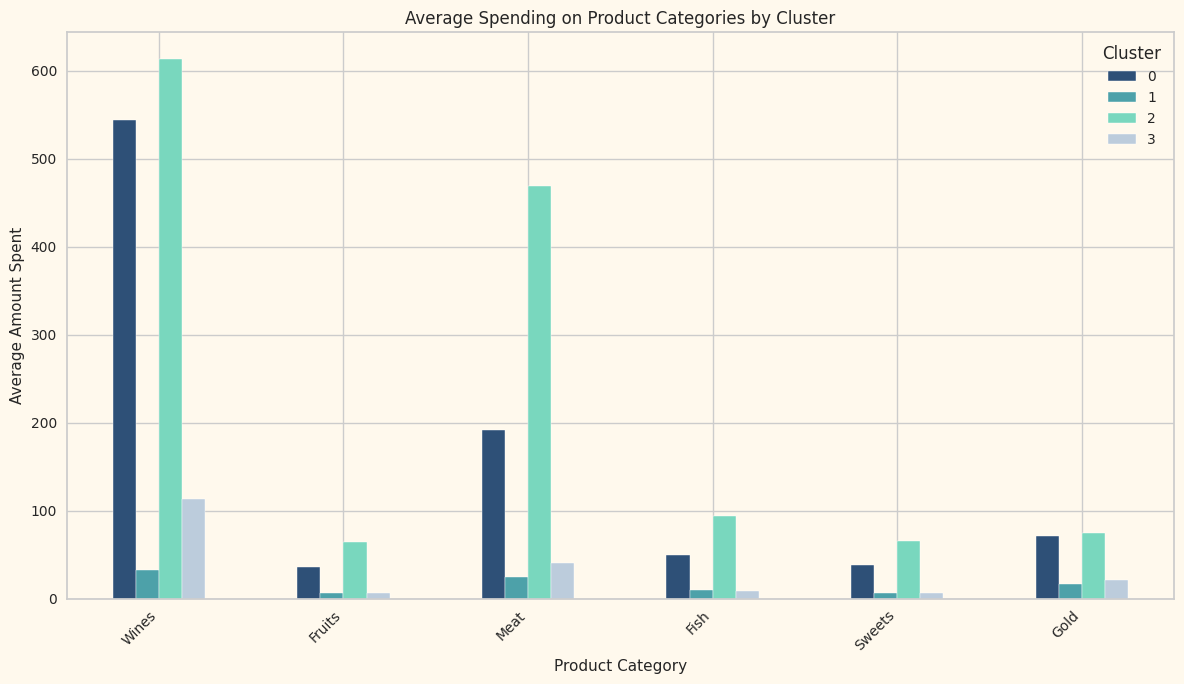

In [38]:
product_cols = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

# Group data by clusters and calculate the mean spending for each product category
product_spending_summary = data.groupby('Clusters')[product_cols].mean().reset_index()

print("Average Spending on Product Categories per Cluster:")
display(product_spending_summary)

# Plot the average spending on each product category per cluster
product_spending_summary.set_index('Clusters').T.plot(kind='bar', figsize=(12, 7), colormap=cmap)
plt.title('Average Spending on Product Categories by Cluster')
plt.xlabel('Product Category')
plt.ylabel('Average Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [42]:
import matplotlib.colors # Import matplotlib.colors for to_hex function

def highlight_value_gradient(s, cmap_name='Greens'):
    # Apply a color gradient based on the numerical values in the series
    # This will color higher values with a darker green
    return ['background-color: %s' % matplotlib.colors.to_hex(plt.cm.get_cmap(cmap_name)(v)) for v in s/s.max()]

print("Cluster Summary with Conditional Formatting (Higher values greener):")
# Apply gradient styling to 'Spent' and 'Income' columns
display(cluster_summary.style.apply(highlight_value_gradient, subset=['Spent', 'Income'], axis=0)
                       .applymap(lambda x: 'background-color: lightgray' if x == 'high' else 'background-color: lightblue' if x == 'medium' else 'background-color: beige', subset=['Spent_Category', 'Income_Category']))

Cluster Summary with Conditional Formatting (Higher values greener):


,Clusters,Spent,Income,Spent_Category,Income_Category,Description
0,0,929.056604,63046.354717,medium,high,"Medium Spenders, High Income"
1,1,96.836938,30749.931780,low,low,"Low Spenders, Low Income"
2,2,1381.106122,75646.183673,high,high,"High Spenders, High Income"
3,3,196.169205,43944.131980,low,low,"Low Spenders, Low Income"


* The plot above clearly shows that Cluster 1 represents the largest group of customers, closely followed by Cluster 0. This insight can help in targeting marketing strategies based on spending patterns for each cluster.

* Next, let's explore the performance of our campaigns in the past.

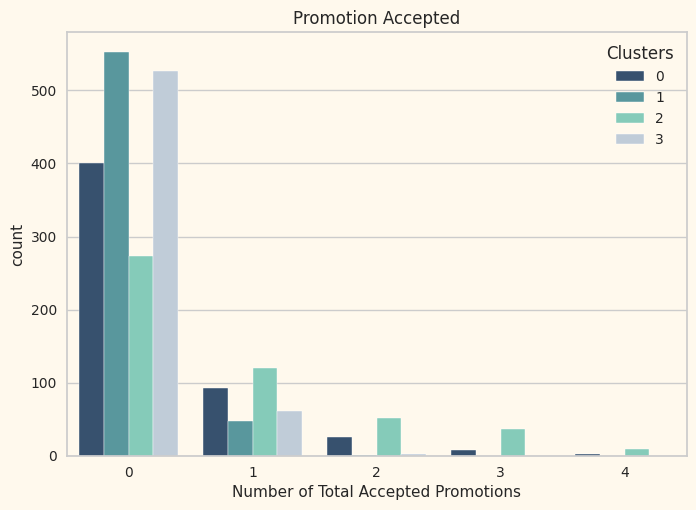

In [35]:
# Calculate total promotions accepted by each customer
data["Total_Promos"] = data["AcceptedCmp1"] + data["AcceptedCmp2"] + data["AcceptedCmp3"] + data["AcceptedCmp4"] + data["AcceptedCmp5"]

# Visualize the number of promotions accepted across clusters
plt.figure()
pl = sns.countplot(x=data["Total_Promos"], hue=data["Clusters"], palette=pal)

# Add title and labels to the plot
pl.set_title("Promotion Accepted")
pl.set_xlabel("Number of Total Accepted Promotions")

# Display the plot
plt.show()

# 5. Communicate results:

* Provide textual description of your work.
* Use visualizations to simplify your findings, and communicate it.
* Any decisions based on facts ?

# Profiling the Clusters

* Now that we have formed the clusters and analyzed their purchasing habits, let's explore the profiles of customers in each cluster. Our goal is to identify the "star" customers and those who need more attention from the marketing team.

* To do this, I will visualize some of the key features indicative of customers' personal traits within each cluster. Based on these visualizations, we will draw conclusions about the nature of each cluster and define strategies for targeted marketing.

<Figure size 800x600 with 0 Axes>

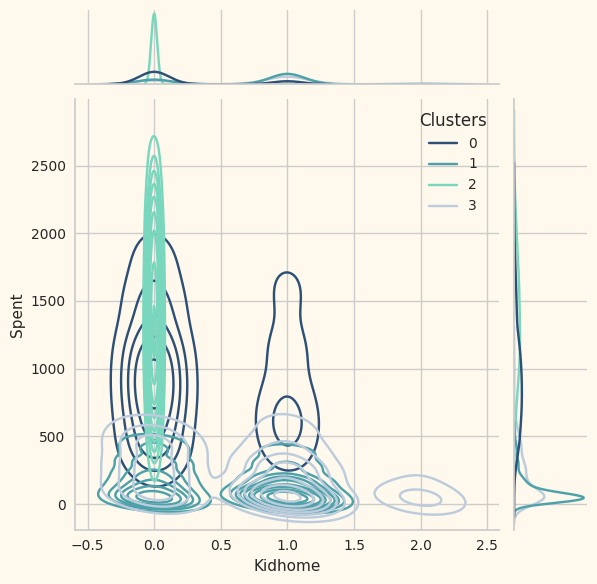

<Figure size 800x600 with 0 Axes>

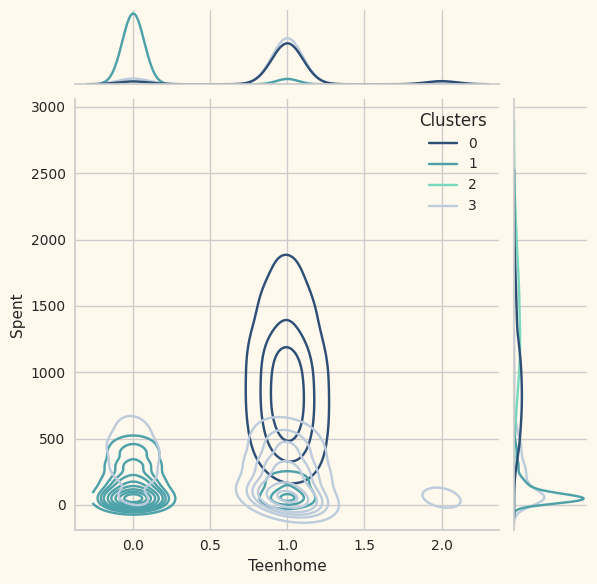

<Figure size 800x600 with 0 Axes>

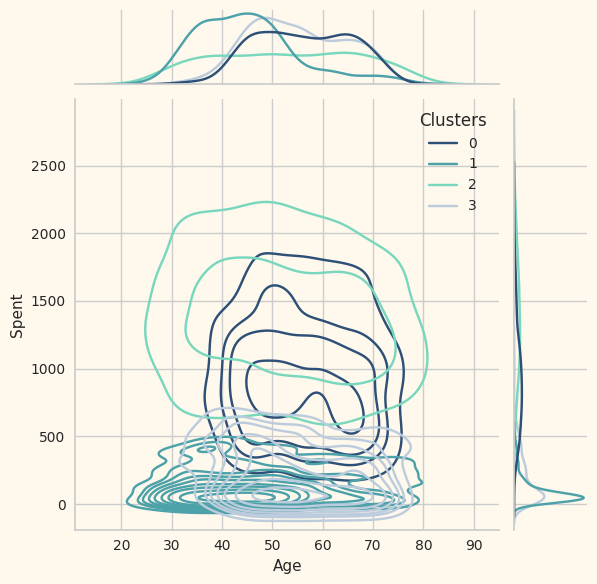

<Figure size 800x600 with 0 Axes>

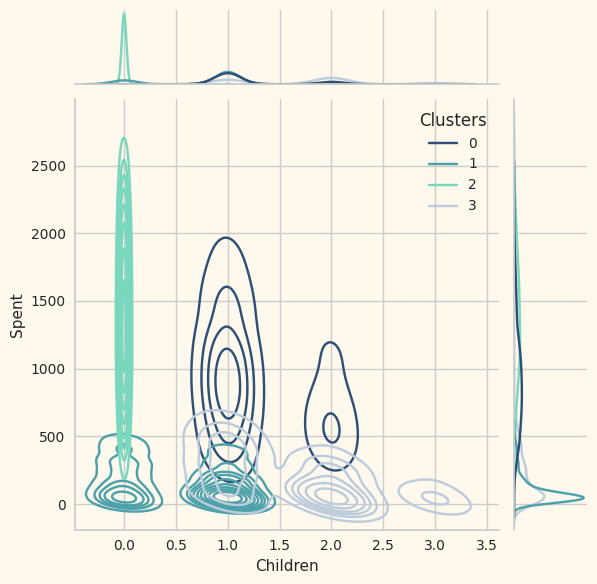

<Figure size 800x600 with 0 Axes>

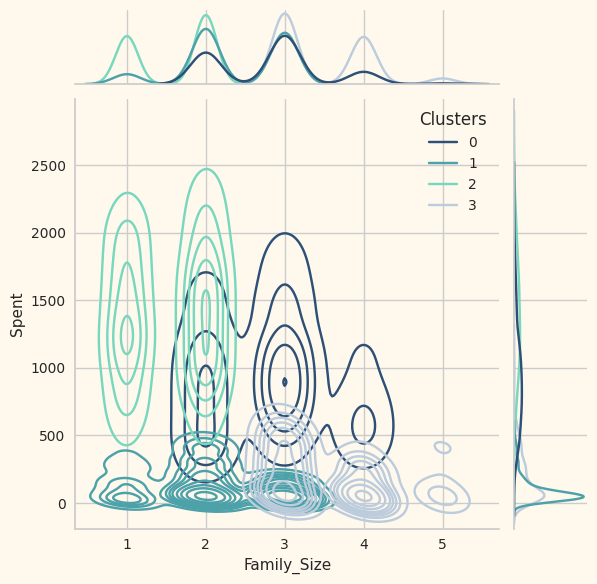

<Figure size 800x600 with 0 Axes>

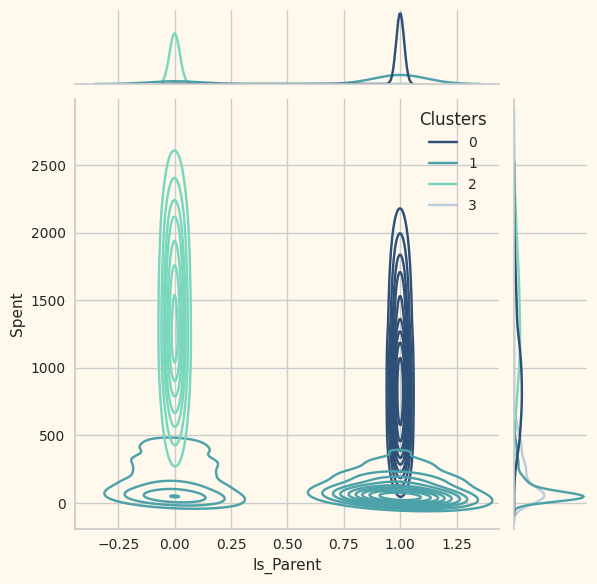

<Figure size 800x600 with 0 Axes>

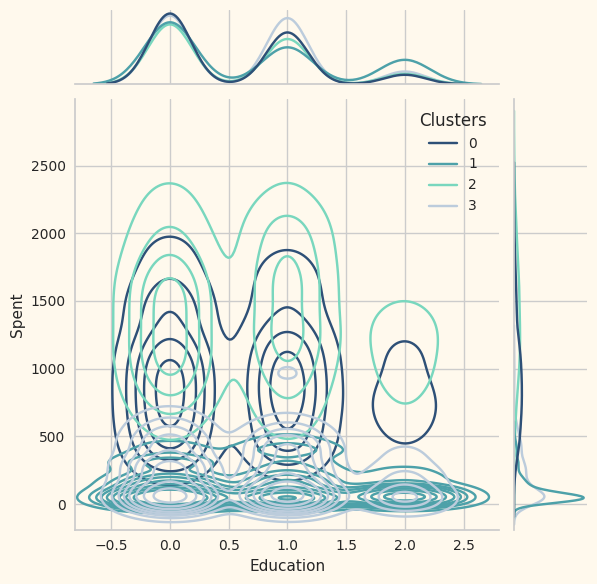

<Figure size 800x600 with 0 Axes>

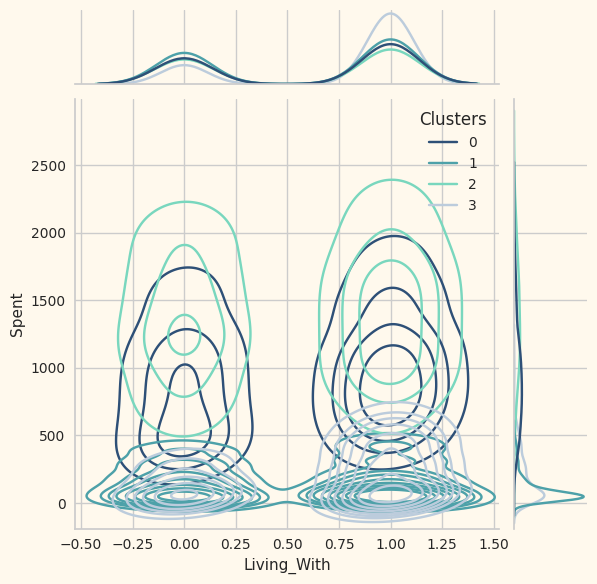

In [36]:
# Analyzing the relationship between personal traits and spending habits across clusters

personal_features = ["Kidhome", "Teenhome", "Age", "Children", "Family_Size", "Is_Parent", "Education", "Living_With"]

# Plotting KDE jointplots for each personal feature against spending, grouped by clusters
for feature in personal_features:
    plt.figure(figsize=(8, 6))
    sns.jointplot(x=data[feature], y=data["Spent"], hue=data["Clusters"], kind="kde", palette=pal)
    plt.show()

# Profiling the Clusters:¶
The following observations summarize the characteristics of customers within each cluster:

## Cluster 0:
* Predominantly parents.
* Family size: Between 2 to 4 members.
* Includes single-parent households.
* Majority have a teenager in the household.
* Members tend to be older.

## Cluster 1:
* Predominantly non-parents.
* Family size: Maximum of 2 members.
* A slight majority of couples over singles.
* Covers all age groups.
* Represents a high-income demographic.

## Cluster 2:
* Majority are parents.
* Family size: Maximum of 3 members.
* Primarily families with one child (non-teenager).
* Members are relatively younger.

## Cluster 3:
* Predominantly parents.
* Family size: Between 2 to 5 members.
* Majority have teenagers in the household.
* Members tend to be older.
* Represents a lower-income group.

# Conclusion¶
* In this project, unsupervised clustering was performed to segment customers.
* Dimensionality reduction was applied prior to performing Agglomerative/Hierarchial Clustering.
* Four distinct clusters were identified, which were then profiled based on **family structure, income, and spending patterns**
* These insights can be leveraged to design more targeted and effective marketing strategies.